# IMPORT LIBRARIES

In [15]:
import os
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import librosa
import soundfile as sf
from pydub import AudioSegment
from pydub.utils import which
from sklearn.model_selection import train_test_split
from sklearn.model_selection import GroupShuffleSplit

# RAVDESS


In [ ]:
Ravdess = "dataset\\ravdess\\"

data = []

emotion_map = {
    1: "Neutral",
    2: "Calm",
    3: "Happy",
    4: "Sad",
    5: "Angry",
    6: "Fearful",
    7: "Disgust",
    8: "Surprised",
}

for dir in os.listdir(Ravdess):
    for file in os.listdir(os.path.join(Ravdess, dir)):
        filename, _ = os.path.splitext(file)
        parts = filename.split("-")
        emotion_code = int(parts[2])
        emotion = emotion_map.get(emotion_code, "Unknown")
        path = os.path.join(Ravdess, dir, file)
        data.append([path, emotion])

Ravdess_df = pd.DataFrame(data, columns=["path", "emotion"])

sns.countplot(x=Ravdess_df["emotion"])
plt.title("Distribution of Emotion Labels")
plt.xlabel("Emotion")
plt.ylabel("Count")
plt.show()

# CREMA-D 

In [19]:
CremaD = "dataset\\CREMA-D\\AudioWAV\\"

data = []

emotion_map = {
    "ANG": "Anger",
    "DIS": "Disgust",
    "FEA": "Fear",
    "HAP": "Happy",
    "NEU": "Neutral",
    "SAD": "Sad",
}


for file in os.listdir(CremaD):
    filename, _ = os.path.splitext(file)
    parts = filename.split("_")

    # Emotion
    emotion_code = parts[2]
    emotion = emotion_map.get(emotion_code, "Unknown")

    # Speaker
    speaker = parts[0]

    # Path
    path = os.path.join(CremaD, file)

    data.append([speaker, emotion, path])

CremaD_df = pd.DataFrame(data, columns=["speaker", "emotion", "path"])
print(CremaD_df.count())

speaker    7442
emotion    7442
path       7442
dtype: int64


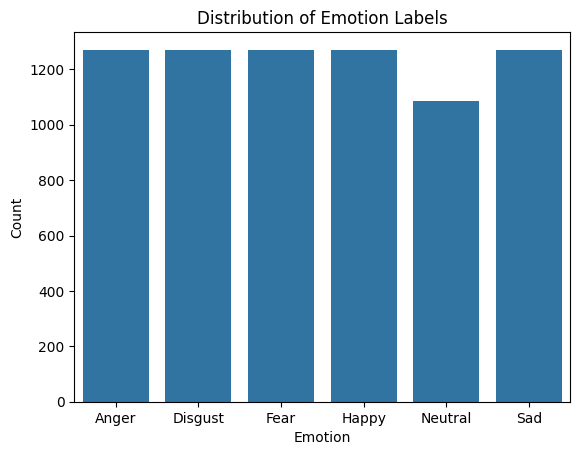

In [12]:
sns.countplot(x=CremaD_df["emotion"])
plt.title("Distribution of Emotion Labels")
plt.xlabel("Emotion")
plt.ylabel("Count")
plt.show()

## Split dataset by Speaker (8:2)

In [21]:
gss = GroupShuffleSplit(test_size=0.2, n_splits=1, random_state=42)

train_idx, test_idx = next(gss.split(CremaD_df, groups=CremaD_df["speaker"]))

train_df = CremaD_df.iloc[train_idx].reset_index(drop=True)
test_df = CremaD_df.iloc[test_idx].reset_index(drop=True)

print(train_df.count())
print(test_df.count())

speaker    5890
emotion    5890
path       5890
dtype: int64
speaker    1552
emotion    1552
path       1552
dtype: int64


**Output Dataframe to CSV**


In [22]:
def create_csv(df: pd.DataFrame, filename: str):
    csv_dir = "CSVs\\"

    if not os.path.exists(csv_dir):
        os.makedirs(csv_dir)
        print(f"Directory {csv_dir} created.")

    df.to_csv(os.path.join(csv_dir, filename), index=False)

    print(f"CSV file created at: {os.path.join(csv_dir, filename)}")


# create_csv(Ravdess_df, "ravdess.csv")
create_csv(CremaD_df, "cremad.csv")
create_csv(train_df, "cremad_train.csv")
create_csv(test_df, "cremad_test.csv")

CSV file created at: CSVs\cremad.csv
CSV file created at: CSVs\cremad_train.csv
CSV file created at: CSVs\cremad_test.csv


**Silence Removal**


In [ ]:
AudioSegment.converter = which("ffmpeg")

dataset = pd.read_csv("CSVs\\cremad.csv")

location = "cremad_Silence\\"


def detect_leading_silence(dls_audio):
    dls_chunk_size = 10
    dls_silence_threshold = -50.0

    trim_ms = 0
    dls_audio_length = len(dls_audio)

    while trim_ms < dls_audio_length:
        chunk_dBFS = dls_audio[trim_ms : trim_ms + dls_chunk_size].dBFS
        if chunk_dBFS > dls_silence_threshold:
            break
        trim_ms += dls_chunk_size

    return trim_ms


name = 0
errors = 0
file_data = []

for _, row in dataset.iterrows():
    file_name = f"{location}{name}.wav"

    try:
        audio = AudioSegment.from_file(row["path"], format="wav")
    except:  # noqa: E722
        audio = AudioSegment.from_file(row["path"])

    start_trim = detect_leading_silence(audio)
    end_trim = detect_leading_silence(audio.reverse())

    duration = len(audio)
    new_audio = audio[start_trim : duration - end_trim]

    if len(new_audio) > 0:
        os.makedirs(os.path.dirname(file_name), exist_ok=True)
        new_audio.export(file_name, format="wav")
    else:
        audio.export(file_name, format="wav")
        errors += 1
        print(f"Error processing {row['path']}, saved original audio.")

    file_data.append([file_name, row["emotion"]])
    name += 1

CremaD_silence = pd.DataFrame(file_data, columns=["path", "emotion"])
create_csv(CremaD_silence, "cremad_silence_removed.csv")

**Dataset partitioning**


In [ ]:
cremad_augmented = pd.read_csv("CSVs\\cremad.csv")
X = cremad_augmented["path"]
y = cremad_augmented["emotion"]

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp
)

print(f"Train: {len(X_train)}, Val: {len(X_val)}, Test: {len(X_test)}")

create_csv(pd.DataFrame({"path": X_train, "emotion": y_train}), "cremad_train.csv")
create_csv(pd.DataFrame({"path": X_val, "emotion": y_val}), "cremad_val.csv")
create_csv(pd.DataFrame({"path": X_test, "emotion": y_test}), "cremad_test.csv")

## Data augmentation (Only train set)


In [26]:
import random


cremad_train = pd.read_csv("CSVs\\cremad_train.csv")
location = "cremad_Augmented\\"
os.makedirs(location, exist_ok=True)


def noise(n_data):
    noise_amp = 0.005 * np.random.uniform() * np.max(np.abs(n_data))
    return n_data + noise_amp * np.random.normal(size=n_data.shape[0])


def stretch(s_data):
    s_rate = np.random.uniform(0.95, 1.05)
    return librosa.effects.time_stretch(s_data, rate=s_rate)


def pitch(p_data, p_sampling_rate):
    p_pitch_factor = np.random.uniform(-1, 1)
    return librosa.effects.pitch_shift(
        p_data, sr=p_sampling_rate, n_steps=p_pitch_factor
    )


name = 0
file_data = []

for _, row in cremad_train.iterrows():
    data, sampling_rate = librosa.load(row["path"], sr=None)

    # Original audio
    file_name = f"{location}{name}.wav"
    sf.write(file_name, data, sampling_rate)

    file_data.append([row["speaker"], row["emotion"], file_name])
    name += 1

    # Randomly select an augmentation type
    aug_type = random.choices(
        ["noise", "stretch", "pitch"], weights=[0.4, 0.3, 0.3], k=1
    )[0]

    augment_map = {
        "noise": lambda: noise(data),
        "stretch": lambda: stretch(data),
        "pitch": lambda: pitch(data, sampling_rate),
    }

    aug_data = augment_map[aug_type]()

    file_name = f"{location}{name}.wav"
    sf.write(file_name, aug_data, sampling_rate)

    file_data.append([row["speaker"], row["emotion"], file_name])
    name += 1

    print(f"Processed {name} files", end="\r", flush=True)


CremaD_augmented = pd.DataFrame(file_data, columns=["speaker", "emotion", "path"])
create_csv(CremaD_augmented, "cremad_augmented.csv")

CSV file created at: CSVs\cremad_augmented.csv
